In [ ]:
import numpy as np
from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
from torch import nn
import math
import seaborn as sns

%matplotlib inline

In [ ]:
swiss_roll = make_swiss_roll(n_samples=10000,noise=0)[0][:,::2]
train_set = torch.tensor(swiss_roll).float()

mu, std = train_set.mean(0), train_set.std(0)
train_set = (train_set - mu)/std
print(train_set.shape)
plt.axes().set_aspect('equal')
plt.scatter(swiss_roll[:,0],swiss_roll[:,1], s=1)
plt.show()

print(f"Data range: x=[{train_set[:,0].min():.2f}, {train_set[:,0].max():.2f}]")
print(f"Data range: y=[{train_set[:,1].min():.2f}, {train_set[:,1].max():.2f}]")

In [47]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view


def plot_loss(output, losses: list):
    losses = np.array(losses)
    niter = len(losses)
    losses_smooth = sliding_window_view(np.pad(losses, (10,10), mode='reflect'), 21).mean(axis=1)

    with sns.axes_style("darkgrid"):
        fig, ax = plt.subplots(1, 1, figsize=(5, 3), dpi=150)
        ax.semilogy(np.arange(niter), losses, linewidth=0.5, alpha=0.5, label='raw')
        ax.semilogy(np.arange(niter), losses_smooth, linewidth=1.5, label='smoothed')
        ax.legend()
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        plt.tight_layout()
        output.update(fig)
        plt.close(fig)


def plot_samples(output, samples_nfen, samples_nfe1, train_set, multistep_steps=15):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

    axes[0].scatter(samples_nfen[:, 0], samples_nfen[:, 1], alpha=0.1, s=1, label=f'{multistep_steps}-step')
    axes[0].scatter(train_set[:, 0], train_set[:, 1], alpha=0.1, s=1, color='red', label='Real')
    axes[0].legend()
    axes[0].set_title(f'NFE-{multistep_steps}')

    axes[1].scatter(samples_nfe1[:, 0], samples_nfe1[:, 1], alpha=0.1, s=1, label='1-step')
    axes[1].scatter(train_set[:, 0], train_set[:, 1], alpha=0.1, s=1, color='red', label='Real')
    axes[1].legend()
    axes[1].set_title('NFE-1')

    plt.tight_layout()
    output.update(fig)
    plt.close(fig)

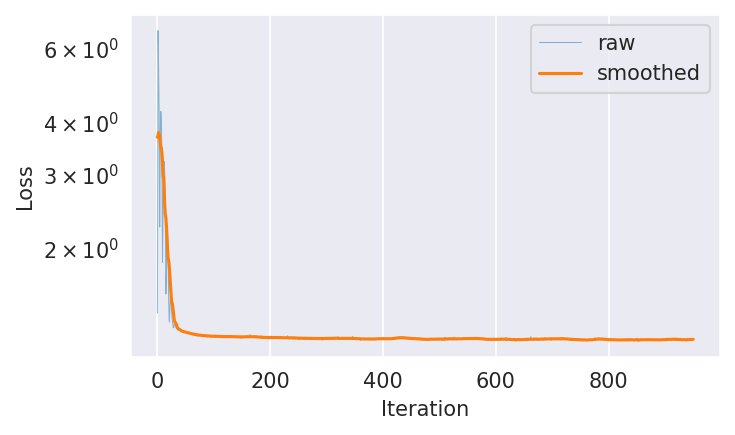

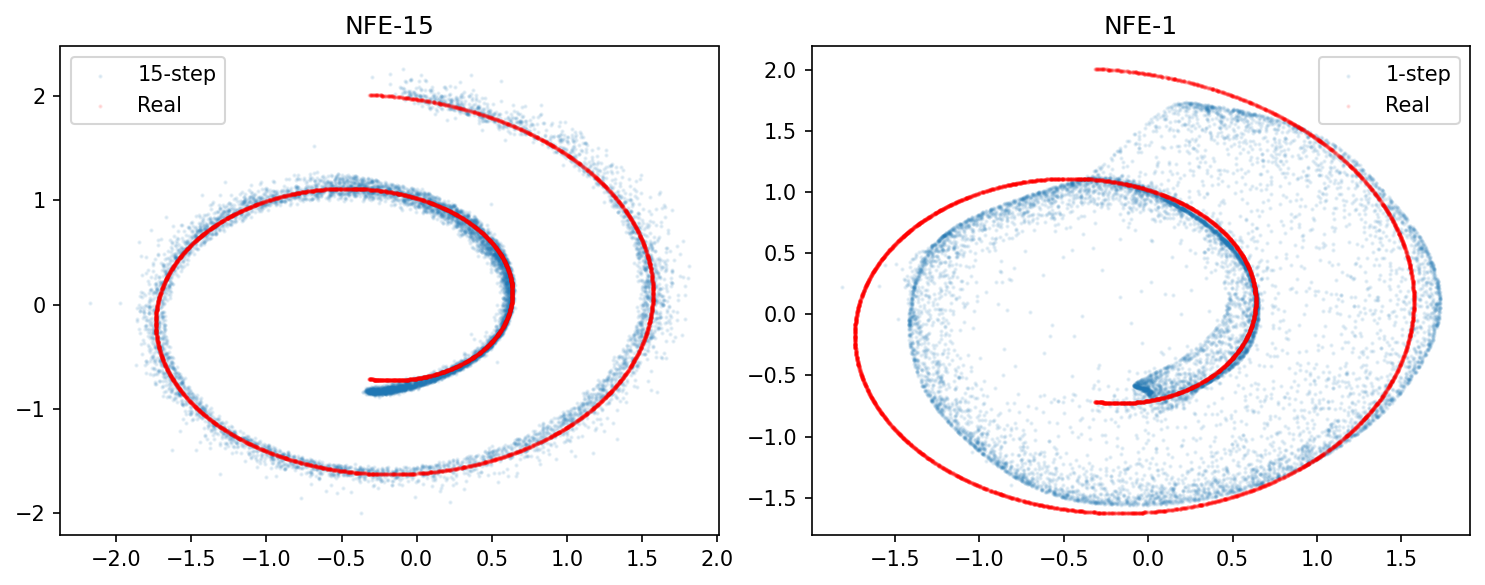

loss = 1.211865: 100%|██████████████████████████████████████████| 1000/1000 [00:26<00:00, 37.87it/s]


In [52]:
# Mean Flows for One-step Generative Modeling
# https://arxiv.org/pdf/2505.13447
import torch.nn.functional as F
from torch.func import jvp
# from torch.autograd.functional import jvp

# Convention is always r, t


# 1 step sampling inference
@torch.no_grad()
def generate_samples_nfe1(model, n_samples):
    device = next(model.parameters()).device
    z = torch.randn(n_samples, 2).to(device)
    model.eval()
    r = torch.zeros((n_samples, 1), device=device) + 1e-1
    t = torch.ones((n_samples, 1), device=device)
    z = z - model(z, r, t)
    return z.cpu()


# n steps
@torch.no_grad()
def generate_samples_multistep(model, n_samples, sample_steps=5, device='cuda'):
    model.eval()

    z = torch.randn(n_samples, 2).to(device)

    t_vals = torch.linspace(1.0, 0.0, sample_steps + 1, device=device)

    for i in range(sample_steps):
        r = torch.full((z.size(0),1), t_vals[i], device=device)
        t = torch.full((z.size(0),1), t_vals[i + 1], device=device)
        r, t = torch.min(r,t), torch.max(r,t)

        v = model(z, r, t)
        z = z - (t-r) * v

    return z.cpu()



# https://github.com/haidog-yaqub/MeanFlow/blob/main/meanflow.py
def sample_rt_gh(batch_size, device):
    mu, sigma = -0.4, 1.0
    flow_ratio = 0.5
    normal_samples = np.random.randn(batch_size, 2).astype(np.float32) * sigma + mu
    samples = 1 / (1 + np.exp(-normal_samples))  # Apply sigmoid

    # Assign t = max, r = min, for each pair
    t_np = np.maximum(samples[:, 0], samples[:, 1])
    r_np = np.minimum(samples[:, 0], samples[:, 1])

    num_selected = int(flow_ratio * batch_size)
    indices = np.random.permutation(batch_size)[:num_selected]
    r_np[indices] = t_np[indices]

    t = torch.tensor(t_np, device=device)[:,None]
    r = torch.tensor(r_np, device=device)[:,None]
    return r, t


def train_step(x, model, optimizer):
    """Mean Flow Identity Derivative leads to a definition
    for target average velocity u_tgt that depends on instantaneous velocity v and (t-r) times
    the time derivative of average velocity u. This is what we model here instead of v (unlike in FM)
    the total derivative of u is du/dz . dz/dt + du / dt . dt/dt (1) + du / dr . dr/dt (0)
    this can be computed using the JVP operator from forward Autodiff in torch.func.
    """
    r,t = sample_rt_gh(len(x), x.device)

    assert ((t-r)>=0 ).all(), "t < r!"

    e = torch.randn_like(x)
    z = (1-t) * x + t * e
    v_target = e - x

    zero = torch.zeros_like(t)
    one = torch.ones_like(r)


    # def u_func(z, r, t):
    #     h = t - r
    #     return model(z, t, h)

    v = model(z, t, t)
    u, dudt = jvp(model, (z, r, t), (v.detach(), zero, one))

    # in "improved mean flow", we reverse the mean flow identity equation
    # in mean flow we say: u = v - (t-r) dudt (this comes naturally from u = 1./(1-r) \int v(z_tau) dtau)
    # here we say the opposite: v = u + (t-r) dudt, since we have a good target for v_target = e-x, we will supervise u with
    # the "V-loss" = (v-v_target)**2
    # the other difference here is that the jvp is done with the real v(z_t), not (e-x)

    V = u + (t-r) * dudt.detach()

    loss = (V - v_target)**2

    loss = loss.sum(dim=1)
    norm_eps = 1e-3
    norm_p = 0.75
    adp_wt = (loss.detach() + norm_eps) ** norm_p
    loss = loss / adp_wt
    loss = loss.mean()


    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return loss



# problem of gradient?
class Residual(nn.Module):
    def __init__(self, num_in):
        super(Residual, self).__init__()
        self.lin = nn.Linear(num_in, num_in)
        self.norm = nn.LayerNorm(num_in)

    def forward(self, x):
        y = F.gelu(self.norm(self.lin(x))) + x
        return y


class TinyMLP(nn.Module):
    """Tiny MLP Conditioned on time"""
    def __init__(self, num_in, hidden):
        super(TinyMLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_in + 2, hidden),
            nn.GELU(),

            Residual(hidden),
            Residual(hidden),
            Residual(hidden),
            Residual(hidden),
            Residual(hidden),
            Residual(hidden),
            Residual(hidden),

            nn.GELU(),
            nn.Linear(hidden, num_in)
        )

    def forward(self, x, r, t):
        x_t = torch.cat((x, r, t), dim=1)
        return self.mlp(x_t)



def train(data, net, niter, lr):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    net.to(device)
    data = data.to(device)

    # Create display handles once (run this cell first)
    loss_output = display(display_id=True)
    samples_output = display(display_id=True)

    optim = torch.optim.Adam(net.parameters(), lr=lr)
    batch_size = 2048 * 16
    losses = []
    for itr in (pbar := tqdm(range(niter), ncols=100)):
        idx = torch.randperm(len(data))[:batch_size]
        x = data[idx].contiguous()
        loss = train_step(x, net, optim)
        losses.append(loss.item())
        pbar.set_description(f"loss = {loss.item():06f}")

        if itr%50==0:
            plot_loss(loss_output, losses)

            samples_nfen = generate_samples_multistep(net, 10000, 15)
            samples_nfe1 = generate_samples_nfe1(net, 10000)

            plot_samples(samples_output, samples_nfen, samples_nfe1, train_set)
    return losses


niter = 1000
lr = 3e-2
net = TinyMLP(2, 256)
net.train()

losses = train(train_set, net, niter, lr)